# Investigation of the focal plane shift of toroid mirror
khchan@lbl.gov awojdyla@lbl.gov, Sep 2025

This script is based on blop 0.71

using `python 3.10.9` environment


In [56]:
%matplotlib inline

import Shadow
import numpy as np
import matplotlib as mpl
from pathlib import Path
from matplotlib import pyplot as plt

In [57]:
# getting the beam size in for any beam shape
def beam_rms_size(x, y, intensity):
    """
    Compute the RMS (root mean square) beam size and centroid from ray data.

    This function calculates the second-moment beam size in both X and Y
    directions directly from a list of ray positions, using only rays
    that exist (I > 0).

    Parameters
    ----------
    x : 1D numpy.ndarray
        Array of X positions of rays (in meters, mm, etc.).
    y : 1D numpy.ndarray
        Array of Y positions of rays (same units as x).
    I : 1D numpy.ndarray
        Array of ray existence flags or intensities.
        Rays with I <= 0 are ignored.

    Returns
    -------
    total_rays : int
        Number of rays considered (I > 0).
    sigma_x : float
        RMS beam size in X direction.
    sigma_y : float
        RMS beam size in Y direction.
    x_centroid : float
        Centroid position in X.
    y_centroid : float
        Centroid position in Y.

    Notes
    -----
    - The RMS size is defined as:
        sigma_x = sqrt(mean((x - x_centroid)^2))
        sigma_y = sqrt(mean((y - y_centroid)^2))
      over all valid rays.
    - For a Gaussian beam, the FWHM can be obtained as:
        FWHM = 2.35482 * sigma
    - This method is robust and fast, and does not assume a Gaussian profile.

    Examples
    --------
    >>> total, sigma_x, sigma_y, cx, cy = beam_rms_size_from_rays(x, y, I)
    >>> fwhm_x = 2.35482 * sigma_x
    >>> fwhm_y = 2.35482 * sigma_y
    """
    #mask = np.all((np.abs(x) > 1e-8, np.abs(x) < 2e-3, np.abs(y) > 1e-8, np.abs(y) < 2e-3), 0)
    x_valid = x
    y_valid = y
    I_valid = intensity

    # intensity
    total_intensity = np.sum(intensity)
    # total_rays = len(x_valid)


    # Centroid positions
    # x_centroid = np.mean(x_valid)
    # y_centroid = np.mean(y_valid)

    # RMS sizes
    # sigma_x = np.sqrt(np.mean((x_valid - x_centroid) ** 2))
    # sigma_y = np.sqrt(np.mean((y_valid - y_centroid) ** 2))

    # Weighted centroids
    x_centroid = np.sum(I_valid * x_valid) / total_intensity
    y_centroid = np.sum(I_valid * y_valid) / total_intensity

    # Weighted RMS sizes
    sigma_x = np.sqrt(np.sum(I_valid * (x_valid - x_centroid) ** 2) / total_intensity)
    sigma_y = np.sqrt(np.sum(I_valid * (y_valid - y_centroid) ** 2) / total_intensity)
    # to avoid division by 0
    if I_valid.shape[0] < 50 or sigma_x<1e-10 or sigma_y<1e-10:
        return 1e-5, 100, 100, 100, 100

    return total_intensity, sigma_x, sigma_y, x_centroid, y_centroid

Define the beamline5.3.1 by shadow

In [74]:
"""
# mirror pitch (DOF1)
oe1.X_ROT = 1e-09
# mirror bend (DOF2)
oe1.R_MAJ = 2400.0

# Mono angle – same variable  (DOF3)
oe2.T_INCIDENCE = 75.6898061088
oe2.T_REFLECTION = 75.6898061088
oe3.T_INCIDENCE = 75.6898061088
oe3.T_REFLECTION = 75.6898061088

# slit position (DOF4)
oe4.CX_SLIT = numpy.array([1e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
oe4.CZ_SLIT = numpy.array([1e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# write (1) or not (0) SHADOW files start.xx end.xx star.xx

iwrite = 0
"""

def beamline_531(X_ROT = 0, R_MAJ = 2400, d_screen = 0):
    MONO_ANGLE = 75.6898061088
    SLIT_CX = 0
    SLIT_CZ = 0
    SLIT_RX = 1e-3
    SLIT_RZ = 5e-4
    # Define the object in beamline
    beam = Shadow.Beam()
    oe0 = Shadow.Source()
    oe1 = Shadow.OE()
    oe2 = Shadow.OE()
    oe3 = Shadow.OE()
    oe4 = Shadow.OE()
    oe5 = Shadow.OE()
    oe6 = Shadow.OE()
    
    
    oe0.FDISTR = 3
    oe0.F_PHOT = 0
    oe0.F_POLAR = 0
    oe0.HDIV1 = 0.0
    oe0.HDIV2 = 0.0
    oe0.IDO_VX = 0
    oe0.IDO_VZ = 0
    oe0.IDO_X_S = 0
    oe0.IDO_Y_S = 0
    oe0.IDO_Z_S = 0
    oe0.ISTAR1 = 0
    oe0.NPOINT = 50000
    oe0.PH1 = 8000.0
    oe0.SIGDIZ = 1e-05
    oe0.SIGMAX = 0.0003
    oe0.SIGMAZ = 0.0001
    oe0.VDIV1 = 0.0
    oe0.VDIV2 = 0.0
    
    
    
    oe1.ALPHA = 180.0
    oe1.DUMMY = 100.0
    oe1.FMIRR = 3
    oe1.FWRITE = 1
    oe1.F_EXT = 1
    oe1.F_MOVE = 1
    oe1.R_MAJ = R_MAJ
    oe1.R_MIN = 0.06
    oe1.T_IMAGE = 0.0
    oe1.T_INCIDENCE = 89.7135211024
    oe1.T_REFLECTION = 89.7135211024
    oe1.T_SOURCE = 12.0
    oe1.X_ROT = X_ROT
    oe1.Y_ROT = 0
    
    
    oe2.DUMMY = 100.0
    oe2.FILE_REFL = b'./bragg.dat'
    oe2.FWRITE = 1
    oe2.F_CENTRAL = 1
    oe2.F_CRYSTAL = 1
    oe2.PHOT_CENT = 8000.0
    oe2.R_LAMBDA = 5000.0
    oe2.T_IMAGE = 0.0
    oe2.T_INCIDENCE = MONO_ANGLE # 75.6898061088
    oe2.T_REFLECTION = MONO_ANGLE #75.6898061088
    oe2.T_SOURCE = 10
    
    
    
    oe3.ALPHA = 180.0
    oe3.DUMMY = 100.0
    oe3.FILE_REFL = b'./bragg.dat'
    oe3.FWRITE = 1
    oe3.F_CENTRAL = 1
    oe3.F_CRYSTAL = 1
    oe3.PHOT_CENT = 8000.0
    oe3.R_LAMBDA = 5000.0
    oe3.T_IMAGE = 0.0
    oe3.T_INCIDENCE = MONO_ANGLE # 75.6898061088
    oe3.T_REFLECTION = MONO_ANGLE # 75.6898061088
    oe3.T_SOURCE = 0.2
    
    
    oe4.CX_SLIT = np.array([SLIT_CX, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.CZ_SLIT = np.array([SLIT_CZ, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.DUMMY = 100.0
    oe4.FWRITE = 3
    oe4.F_REFRAC = 2
    oe4.F_SCREEN = 1
    oe4.I_SLIT = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    oe4.N_SCREEN = 1
    oe4.RX_SLIT = np.array([SLIT_RX, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.RZ_SLIT = np.array([SLIT_RZ, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.T_IMAGE = 0.0
    oe4.T_INCIDENCE = 0.0
    oe4.T_REFLECTION = 180.0
    oe4.T_SOURCE = 0.8 + 10 + 0.2
    
    
    
    oe5.DUMMY = 100.0
    oe5.FWRITE = 3
    oe5.F_REFRAC = 2
    oe5.F_SCREEN = 1
    oe5.N_SCREEN = 1
    oe5.T_IMAGE = 0.0
    oe5.T_INCIDENCE = 0.0
    oe5.T_REFLECTION = 180.0
    oe5.T_SOURCE = 1.0 + d_screen

    beam.genSource(oe0)
    beam.traceOE(oe1,1)
    beam.traceOE(oe2,2)
    beam.traceOE(oe3,3)
    beam.traceOE(oe4,4)
    beam.traceOE(oe5,5)

    X = beam.getshcol(1)
    Y = beam.getshcol(3)
    # normalize the intensity by the number of rays
    valid = beam.getshcol(10) > 0
    intensity = (beam.getshcol(7)+beam.getshcol(16))**2 + (beam.getshcol(8)+beam.getshcol(17))**2 + (beam.getshcol(9)++beam.getshcol(18))**2
    mask = valid>0
    print(np.sum(mask))
    print(np.sum(intensity[mask]))
    X = X[mask]
    Y = Y[mask]
    intensity = intensity[mask]
    return X,Y,intensity

In [75]:
X, Y, intensity = beamline_531()

1420
1062.3530029823223


In [76]:
(total_intensity, sigma_x, sigma_y, x_centroid, y_centroid) = beam_rms_size(X, Y, intensity)

In [77]:
total_intensity, sigma_x, sigma_y, x_centroid, y_centroid

(1062.3530029823223,
 0.00031658025635293303,
 0.0001353513269143219,
 6.658319255482801e-06,
 -1.344655739790475e-05)

In [68]:
import numpy as np

# Define the scan ranges
x_rot_values =  np.linspace(-0.0004, 0, 4)  # 50 steps in x_rot
r_maj_values = np.linspace(2000, 2800, 30)     # 50 steps in r_maj

best_power_density = -np.inf
best_params = None

# Store results for analysis/plotting
results = []

for x_rot in x_rot_values:
    for r_maj in r_maj_values:
        # Run beamline simulation
        X, Y, I = beamline_531(x_rot, r_maj)

        # Convert to mm
        X = X * 1e3
        Y = Y * 1e3

        # Get beam stats
        intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)

        # Compute power density
        power_density = intensity / (sigma_x * sigma_y)

        results.append((x_rot, r_maj, power_density))

        # Track best
        if power_density > best_power_density:
            best_power_density = power_density
            best_params = (x_rot, r_maj)

# Report best result
print(f"Best power density: {best_power_density:.4f}")
print(f"Best parameters: x_rot = {best_params[0]:.6f}, r_maj = {best_params[1]:.6f}")

15760
15760.0
15911
15911.0
16163
16163.0
16102
16102.0
16036
16036.0
16255
16255.0
16523
16523.0
16770
16770.0
16226
16226.0
16495
16495.0
16737
16737.0
16480
16480.0
16552
16552.0
16524
16524.0
16410
16410.0
16227
16227.0
16189
16189.0
15957
15957.0
15792
15792.0
15738
15738.0
15346
15346.0
15271
15271.0
14928
14928.0
14790
14790.0
14644
14644.0
14492
14492.0
14313
14313.0
13876
13876.0
13927
13927.0
13591
13591.0
16699
16699.0
16742
16742.0
17093
17093.0
17376
17376.0
17654
17654.0
17510
17510.0
17806
17806.0
17842
17842.0
17798
17798.0
18025
18025.0
18024
18024.0
18054
18054.0
18233
18233.0
18299
18299.0
18097
18097.0
18021
18021.0
18175
18175.0
18060
18060.0
17836
17836.0
17939
17939.0
17600
17600.0
17533
17533.0
17473
17473.0
16979
16979.0
17235
17235.0
16900
16900.0
16600
16600.0
16568
16568.0
16305
16305.0
16374
16374.0
17091
17091.0
17201
17201.0
17297
17297.0
17593
17593.0
17890
17890.0
18138
18138.0
18197
18197.0
18080
18080.0
18329
18329.0
18383
18383.0
18669
18669.0
18380


In [80]:
# testing the focal plane of the toroid mirror
results = []
d_screen_m = np.linspace(-1, 1, 100)     # distance in m 
for d in d_screen_m:
    X, Y, intensity = beamline_531(R_MAJ = 4000, d_screen = d)
    # Convert to mm
    X = X * 1e3
    Y = Y * 1e3

    # Get beam stats
    intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, intensity)

    # Compute power density
    power_density = intensity / (sigma_x * sigma_y)
    results.append(power_density)

1992
1537.644893905157
2098
1601.4607436932306
1957
1496.7464421112236
2108
1601.0641411411762
2030
1557.6035733850651
1912
1464.4693684757776
2083
1606.1635313999368
1982
1517.452273021124
1933
1481.3513919964128
1948
1479.7687954595585
1998
1520.4102335833045
1995
1539.4023543345893
2034
1550.4132420390333
2072
1578.0153803871453
1956
1491.0011192316097
2052
1552.3849746094127
2038
1565.1509183885669
2088
1601.4575464969148
1988
1520.543556502885
2024
1560.8561456556893
1996
1512.6886163217864
1952
1482.7258457038133
1994
1521.3281252464835
2063
1567.548963736021
2057
1582.454063649635
2031
1562.7326517259883
1938
1490.2991465460836
2012
1532.246909717964
2024
1539.3257363129505
2072
1588.115228892113
1978
1515.0473248779651
1984
1522.1209246583112
2049
1561.3632067796561
2003
1526.9852863428919
1999
1529.7820314048834
2043
1554.208607044216
2009
1537.315914809407
1915
1464.0291789654084
2005
1529.4887947411898
1991
1525.2238367465734
2040
1558.9368773289132
2048
1560.7990959447607
2

Text(0, 0.5, 'power density (/mm^2)')

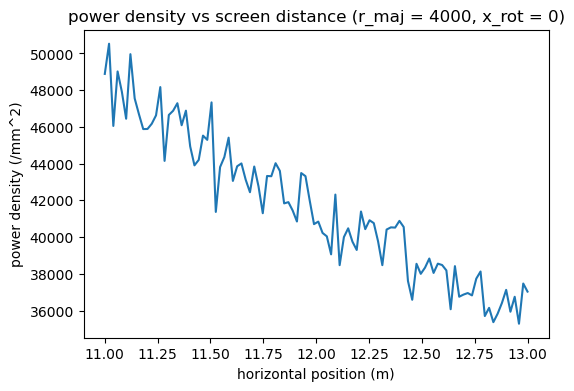

In [81]:
plt.figure(figsize = (6,4))
plt.plot(d_screen_m + 12, results)
plt.title('power density vs screen distance (r_maj = 4000, x_rot = 0)')
plt.xlabel('horizontal position (m)')
plt.ylabel('power density (/mm^2)')

18478
18478.0
18478.0 0.28670381195665734 0.08364661112172074 0.002317706104517169 0.01909004860826441
18478
18478.0
18478.0 0.21159526259207506 0.08247440525992915 -0.000796750349978137 0.032478454872293595


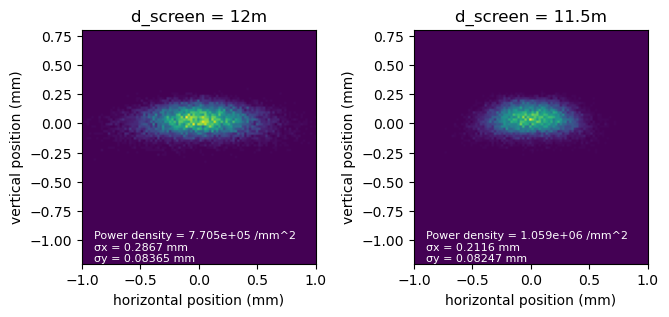

In [73]:
plt.figure(figsize=(10, 4))

# Overall figure title
# plt.suptitle('Multi-dimension optimization Beam profile on screen 2 x 2 mm', fontsize=14)

# --- First subplot ---
x_rot =  0                                                                                                                                                                                                                                                                                                                                             
r_maj =  2800.0
mono_angle = 75.6898061088
slit_rx = 1e-3
slit_rz = 5e-4
slit_cx = 0.0
slit_cz = 0.0    
X, Y, I = beamline_531(x_rot, r_maj)#, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)
        
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 1)
hist1, xedges, yedges = np.histogram2d(
    X, Y, bins=100, range=[[-1, 1], [-1.2, 0.8]], weights=I
)
plt.title('d_screen = 12m')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Power density = {intensity/sigma_x/sigma_y:.4g} /mm^2\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')

# --- Second subplot ---
x_rot =  0                                                                                                                                                                                                                                                                                                                                             
r_maj =  2800.0
mono_angle = 75.6898061088
slit_rx = 1e-3
slit_rz = 5e-4
slit_cx = 0.0
slit_cz = 0.0    
X, Y, I = beamline_531(x_rot, r_maj, d_screen = -0.5)#, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)
        
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 2)
hist1, xedges, yedges = np.histogram2d(
    X, Y, bins=100, range=[[-1, 1], [-1.2, 0.8]], weights=I
)
plt.title('d_screen = 11.5m')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Power density = {intensity/sigma_x/sigma_y:.4g} /mm^2\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')
plt.tight_layout()